 # ML Surrogate for PD-Controlled Tilt System

We learn:

$$
(v, R, k_p, k_{rate}) \rightarrow a_{felt,max}
$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

## Load Dataset

The dataset generated from the simulator is loaded and prepared for training.

In [2]:
df = pd.read_csv("dataset.csv")

X = df[["v", "R", "kp", "krate"]]
y = df["max_felt"]

## Train-Test Split

The dataset is split into training and testing sets to evaluate model performance.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Normalization

Input features are normalized using standard scaling to improve training performance.

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

A feedforward neural network (MLPRegressor) is trained to learn the mapping:

\[
(v, R, k_p, k_{rate}) \rightarrow a_{felt, max}
\]

In [5]:
model = MLPRegressor(
    hidden_layer_sizes=(32,32),
    max_iter=2000
)

model.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(32, 32), max_iter=2000)

## Model Evaluation

Model performance is evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Square Error (RMSE)

In [15]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 0.04719596801972837
RMSE: 0.06106037557532649


## Model Accuracy Comparison

We compare ML predictions against the physics-based simulator.

### Prediction vs Ground Truth

A scatter plot comparing ML predictions with simulator outputs.

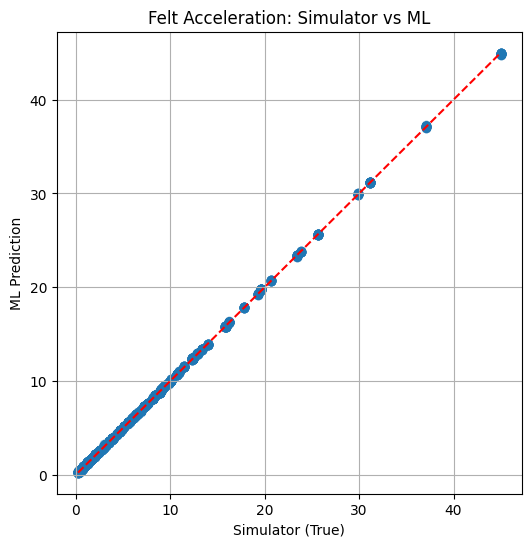

In [49]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Simulator (True)")
plt.ylabel("ML Prediction")
plt.title("Felt Acceleration: Simulator vs ML")

plt.grid()
plt.savefig("ml_vs_simulator.png", dpi=300, bbox_inches='tight')

plt.show()

### Error Distribution

Histogram showing distribution of prediction errors.

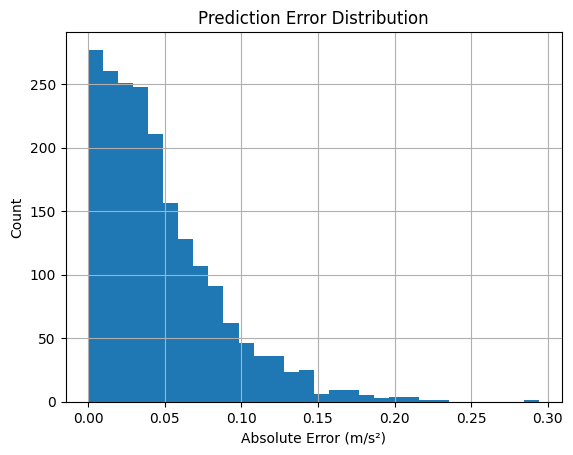

In [50]:
errors = np.abs(y_test - y_pred)

plt.hist(errors, bins=30)

plt.xlabel("Absolute Error (m/s²)")
plt.ylabel("Count")
plt.title("Prediction Error Distribution")

plt.grid()
plt.savefig("error_hist.png", dpi=300, bbox_inches='tight')

plt.show()


In [19]:
def tilt_dynamics_control(t, state, v, R, params):
    phi, phi_dot = state

    g = params["g"]
    kp = params["kp"]
    krate = params["krate"]

    a_lat = v**2 / R
    phi_des = np.arctan(a_lat / g)

    phi_ddot = kp * (phi_des - phi) - krate * phi_dot

    return [phi_dot, phi_ddot]

In [37]:
def simulate_case_full(v, R, params, t_final=5.0):

    t_eval = np.linspace(0, t_final, 200)

    sol = solve_ivp(
        lambda t, y: tilt_dynamics_control(t, y, v, R, params),
        [0, t_final],
        [0, 0],
        t_eval=t_eval
    )

    phi = sol.y[0]
    phi_dot = sol.y[1]
    t = sol.t

    effort = np.gradient(phi_dot, t)

    a_lat = v**2 / R
    a_felt = a_lat - params["g"] * np.sin(phi)
    return {
        "t": t,
        "phi": phi,
        "a_felt": a_felt,
        "effort": effort
    }

In [38]:
params = {"g": 9.81, "kp": 5, "krate": 2}

v_test = 20
R_test = 50
kp_test = 5
kr_test = 2

params["kp"] = kp_test
params["krate"] = kr_test

res = simulate_case_full(v_test, R_test, params)
true_val = np.max(np.abs(res["a_felt"]))

X_input = scaler.transform(
    pd.DataFrame([[v_test, R_test, kp_test, kr_test]],
                 columns=["v","R","kp","krate"])
)

pred_val = model.predict(X_input)[0]

print("Simulator:", true_val)
print("ML prediction:", pred_val)
print("Error:", abs(true_val - pred_val))

Simulator: 8.0
ML prediction: 8.014247672895525
Error: 0.014247672895525199


### Multiple Case Comparison

Comparison across different driving conditions.

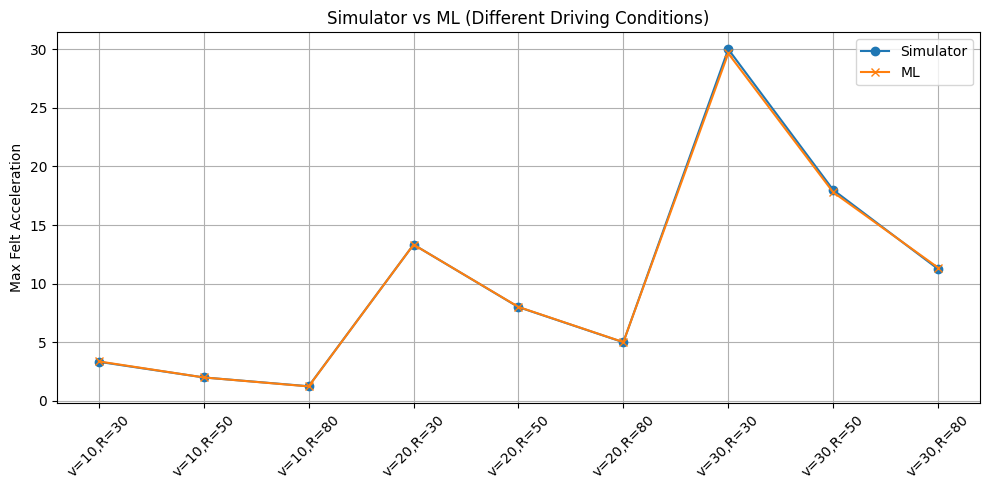

In [51]:
labels = []

for v in v_vals:
    for R in R_vals:
        labels.append(f"v={v},R={R}")

plt.figure(figsize=(10,5))

plt.plot(true_vals, marker='o', label="Simulator")
plt.plot(pred_vals, marker='x', label="ML")

plt.xticks(range(len(labels)), labels, rotation=45)

plt.ylabel("Max Felt Acceleration")
plt.title("Simulator vs ML (Different Driving Conditions)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("multi_case.png", dpi=300, bbox_inches='tight')

plt.show()


## Parameter Sensitivity Analysis

We compare how the simulator and ML model respond to changes in control parameters (kp and krate).

This helps verify whether the ML surrogate captures the effect of control tuning.

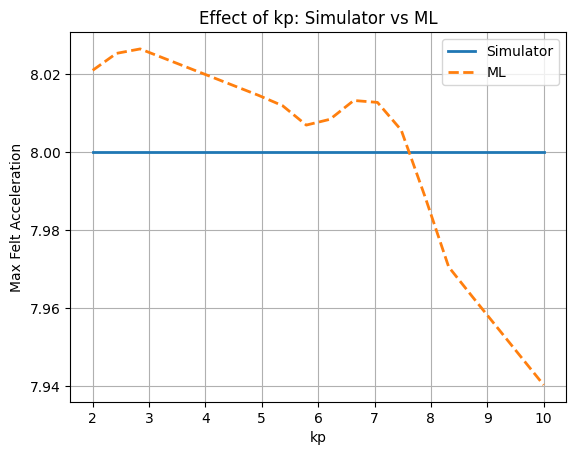

In [52]:
kp_vals = np.linspace(2, 10, 20)

sim_vals = []
ml_vals = []

v = 20
R = 50
kr = 2

for kp in kp_vals:

    # recreate params (IMPORTANT FIX)
    params_loop = {
        "g": 9.81,
        "kp": kp,
        "krate": kr
    }

    # simulator
    res = simulate_case_full(v, R, params_loop)
    sim_val = np.max(np.abs(res["a_felt"][:50]))

    # ML
    X_input = scaler.transform(
        pd.DataFrame([[v, R, kp, kr]],
                     columns=["v","R","kp","krate"])
    )

    ml_val = model.predict(X_input)[0]

    sim_vals.append(sim_val)
    ml_vals.append(ml_val)

# 🔥 PLOT (this is what you're missing)
plt.figure()

plt.plot(kp_vals, sim_vals, label="Simulator", linewidth=2)
plt.plot(kp_vals, ml_vals, '--', label="ML", linewidth=2)

plt.xlabel("kp")
plt.ylabel("Max Felt Acceleration")
plt.title("Effect of kp: Simulator vs ML")

plt.legend()
plt.grid()
plt.savefig("kp_sensitivity.png", dpi=300, bbox_inches='tight')

plt.show()


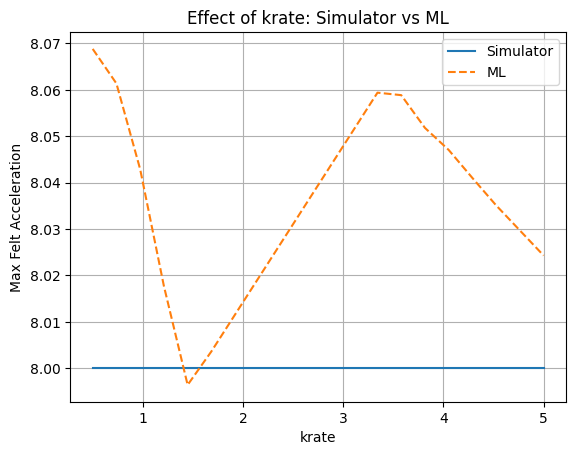

In [53]:
kr_vals = np.linspace(0.5, 5, 20)

sim_vals = []
ml_vals = []

v = 20
R = 50
kp = 5

for kr in kr_vals:

    params["kp"] = kp
    params["krate"] = kr

    res = simulate_case_full(v, R, params)
    sim_val = np.max(np.abs(res["a_felt"]))

    X_input = scaler.transform(
        pd.DataFrame([[v, R, kp, kr]],
                     columns=["v","R","kp","krate"])
    )

    ml_val = model.predict(X_input)[0]

    sim_vals.append(sim_val)
    ml_vals.append(ml_val)

plt.plot(kr_vals, sim_vals, label="Simulator")
plt.plot(kr_vals, ml_vals, '--', label="ML")

plt.xlabel("krate")
plt.ylabel("Max Felt Acceleration")
plt.title("Effect of krate: Simulator vs ML")
plt.legend()
plt.grid()
plt.savefig("krate_sensitivity.png", dpi=300, bbox_inches='tight')

plt.show()


## Optimization Using ML

The ML model is used to find optimal control gains that minimize felt acceleration.

In [41]:
v_test = 20
R_test = 50

best = None
best_val = 1e9

for kp in np.linspace(2, 15, 30):
    for kr in np.linspace(0.5, 5, 30):

        X_input = scaler.transform(
            pd.DataFrame([[v_test, R_test, kp, kr]],
                         columns=["v","R","kp","krate"])
        )

        pred = model.predict(X_input)[0]

        if pred < best_val:
            best_val = pred
            best = (kp, kr)

print("Optimal kp, krate:", best)
print("Minimum felt accel:", best_val)

Optimal kp, krate: (np.float64(15.0), np.float64(4.5344827586206895))
Minimum felt accel: 7.76849563979544


## Computational Efficiency

Comparison of runtime between the simulator and ML model.

In [42]:
import time
from scipy.integrate import solve_ivp
import numpy as np

def simulate_case(v, R, params):
    sol = solve_ivp(
        lambda t, y: tilt_dynamics_control(t, y, v, R, params),
        [0, 5],
        [0, 0]
    )
    return sol.y[0][-1]

params = {"g": 9.81, "kp": 5, "krate": 2}

N = 1000

start = time.time()
for _ in range(N):
    simulate_case(15, 50, params)
sim_time = time.time() - start

X_input = scaler.transform(
    pd.DataFrame([[15, 50, 5, 2]],
                 columns=["v","R","kp","krate"])
)

start = time.time()
for _ in range(N):
    model.predict(X_input)
ml_time = time.time() - start

print("Simulator avg:", sim_time/N)
print("ML avg:", ml_time/N)

Simulator avg: 0.0004553499221801758
ML avg: 3.5795927047729495e-05
